# Morphological processing


Processing TRAIN: 20 images in batches of 10...
  Batch 1: Processing images 0 to 10...
  Batch 2: Processing images 10 to 20...

[Visualization] Error Map for Best Image


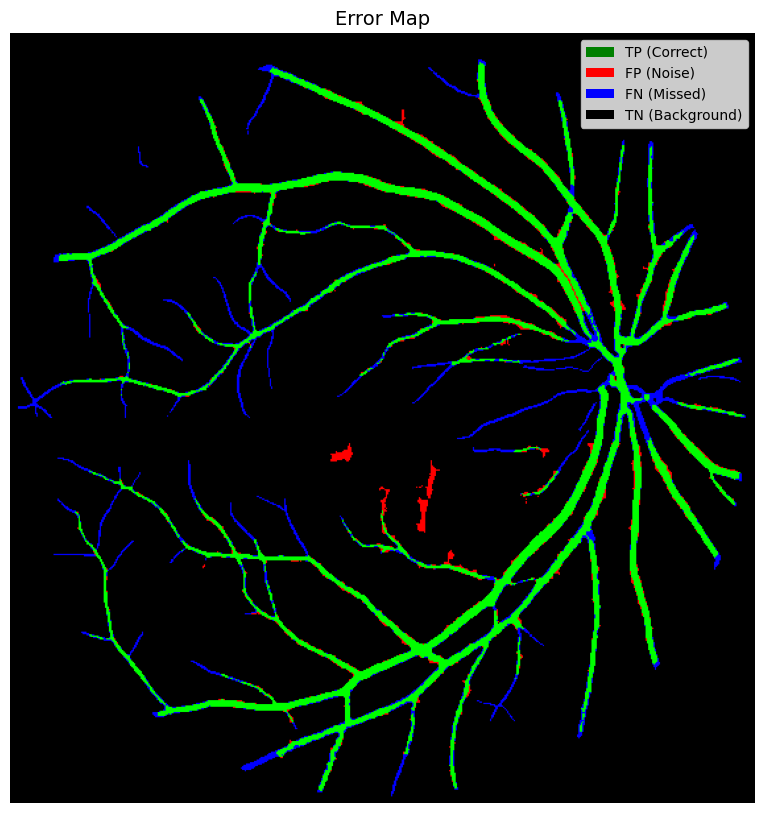


 MORPHOLOGICAL PROCESS ANALYSIS: PERFORMANCE RESULTS
Image      Accuracy     Sensitivity  Precision    Specificity  F1-Score    
------------------------------------------------------------------------------------------
0             96.48       76.22       90.97       99.04       82.94
1             86.32       75.91       42.09       87.56       54.15
2             95.91       72.00       90.25       99.00       80.10
3             95.99       71.40       90.91       99.10       79.98
4             94.81       70.86       90.01       98.72       79.29
5             95.21       68.76       83.42       98.37       75.38
6             96.34       68.48       89.54       99.18       77.61
7             95.20       67.09       82.02       98.35       73.81
8             93.35       60.92       61.73       96.42       61.32
9             94.79       55.76       87.32       99.10       68.06
10            94.79       51.88       95.69       99.73       67.29
11            93.81       50.03

In [5]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import gc
from matplotlib.patches import Patch

# INTEGRATION: Import the external preprocessing module
from preprocess import preprocess

# =====================================================================
# 1. UTILITIES: LOAD & MASKS
# =====================================================================

def get_file_paths(folder_path, max_images=None):
    if not os.path.exists(folder_path): return []
    all_files = sorted(os.listdir(folder_path))
    if max_images: all_files = all_files[:max_images]
    valid_exts = ('.png', '.jpg', '.jpeg', '.tif', '.bmp')
    return [os.path.join(folder_path, f) for f in all_files if f.lower().endswith(valid_exts)]

def load_batch(file_paths):
    images = []
    for fp in file_paths:
        img = cv2.imread(fp)
        if img is not None: images.append(img)
    return images

def get_FOV_masks(dataset):
    masks = []
    for img in dataset:
        # Handle if image is RGB or Green Channel already
        if len(img.shape) == 3: src = img[:,:,1]
        else: src = img
            
        _, binary = cv2.threshold(src, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        mask = np.zeros_like(src)
        if contours:
            largest = max(contours, key=cv2.contourArea)
            cv2.drawContours(mask, [largest], -1, 255, thickness=cv2.FILLED)
        masks.append((mask // 255).astype(np.uint8))
    return masks

# =====================================================================
# 2. POST-PROCESSING (Sensitivity Optimized)
# =====================================================================

def post_process_segmentation(seg_map, threshold=0.08, min_area=30):
    # Thresholding
    binary_map = (seg_map > threshold).astype(np.uint8)
    
    # Morphological Closing (Connect gaps)
    kernel = np.ones((2, 2), np.uint8)
    binary_map = cv2.morphologyEx(binary_map, cv2.MORPH_CLOSE, kernel)
    
    # CCA (Size filtering)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_map, connectivity=8)
    clean_mask = np.zeros_like(binary_map)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            clean_mask[labels == i] = 1
            
    return seg_map * clean_mask

# =====================================================================
# 3. METRICS
# =====================================================================

def calculate_metrics(segmented, ground_truth, mask, threshold):
    gt_binary = (ground_truth > 127).astype(bool)
    pred_binary = (segmented > threshold).astype(bool)
    fov_mask = mask.astype(bool)

    gt_binary &= fov_mask
    pred_binary &= fov_mask

    TP = np.sum(gt_binary & pred_binary)
    TN = np.sum(~gt_binary & ~pred_binary & fov_mask)
    FP = np.sum(~gt_binary & pred_binary)
    FN = np.sum(gt_binary & ~pred_binary)

    denom = TP + TN + FP + FN
    accuracy = (TP + TN) / denom if denom > 0 else 0.0
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    
    f1_score = 0.0
    if (precision + sensitivity) > 0:
        f1_score = 2.0 * (precision * sensitivity) / (precision + sensitivity)

    return {
        "accuracy": accuracy, "sensitivity": sensitivity,
        "specificity": specificity, "precision": precision,
        "f1_score": f1_score, "TP": TP, "TN": TN, "FP": FP, "FN": FN
    }

# =====================================================================
# 4. SEGMENTATION LOGIC
# =====================================================================

def build_morph_input(preproc_list):
    """
    Adapts the output of preprocess.py (list of float images) 
    to uint8 [0-255] format required by the morphological segmenter.
    """
    out = []
    for img_float in preproc_list:
        # Normalize float output (roughly -3 to +3) to 0-255 uint8
        mn, mx = img_float.min(), img_float.max()
        if mx > mn:
            norm = (img_float - mn) / (mx - mn)
        else:
            norm = np.zeros_like(img_float)
            
        out.append((norm * 255.0).astype(np.uint8))
    return out

def morphological_vessel_segmentation(dataset, image_size=565, drive_size=565):
    processed_data = []
    scale_factor = image_size / float(drive_size)
    wc_radius = int(round(2 * scale_factor))
    wc_size = 2 * wc_radius + 1
    kernel_c = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (wc_size, wc_size))

    base_radii = np.arange(1, 9, dtype=np.int32)
    detection_radii = np.maximum(1, np.round(base_radii * scale_factor).astype(np.int32))
    
    kernels_w = {}
    for r in np.unique(detection_radii):
        w_size = 2 * r + 1
        kernels_w[r] = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (w_size, w_size))

    radii_for_scales = detection_radii.tolist()
    num_scales = len(radii_for_scales)
    
    # Weight generation
    num_averaged = (num_scales + 1) // 2
    weights = np.arange(num_averaged, 0, -1, dtype=np.float32)
    weights /= weights.sum()
    weights *= 2.0

    for img_u8 in dataset:
        img_float = img_u8.astype(np.float32) / 255.0
        
        # Morphological Closing (Fill dark holes in bright vessels)
        img_closed = cv2.morphologyEx(img_float, cv2.MORPH_CLOSE, kernel_c)

        scale_results = []
        for r in radii_for_scales:
            kernel_w = kernels_w[r]
            # Opening (Remove bright features smaller than kernel)
            img_opened = cv2.morphologyEx(img_closed, cv2.MORPH_OPEN, kernel_w)
            # Top-hat-like operation: Vessel = Original - Background Estimate
            background_est = np.minimum(img_opened, img_float)
            scale_results.append(img_float - background_est)

        averaged_results = []
        for i in range(0, num_scales, 2):
            if i + 1 < num_scales:
                avg = 0.5 * (scale_results[i] + scale_results[i + 1])
                averaged_results.append(avg)
            else:
                averaged_results.append(scale_results[i])

        final_response = np.zeros_like(img_float, dtype=np.float32)
        for w, res in zip(weights, averaged_results):
            final_response = np.maximum(final_response, w * res)

        min_val, max_val = final_response.min(), final_response.max()
        if max_val > min_val:
            normalized = (final_response - min_val) / (max_val - min_val)
        else:
            normalized = final_response
        processed_data.append(normalized)

    return processed_data

# =====================================================================
# 5. BATCH CONTROLLER
# =====================================================================

def process_dataset_in_batches(img_paths, gt_paths, batch_size=10, set_name="TRAIN", 
                               sensitivity_threshold=0.08, min_area_val=30):
    total_images = len(img_paths)
    all_metrics = []
    best_overall_data = None
    best_overall_f1 = -1.0
    
    print(f"\nProcessing {set_name}: {total_images} images in batches of {batch_size}...")

    for i in range(0, total_images, batch_size):
        batch_img_paths = img_paths[i : i + batch_size]
        batch_gt_paths = gt_paths[i : i + batch_size]
        
        batch_imgs = load_batch(batch_img_paths)
        batch_gts = load_batch(batch_gt_paths)
        
        if not batch_imgs: continue
        print(f"  Batch {i//batch_size + 1}: Processing images {i} to {min(i+batch_size, total_images)}...")

        # 1. FOV Masks
        batch_fov_masks = get_FOV_masks(batch_imgs)
        
        # 2. Preprocessing (Using imported module)
        # Returns list of float images (Vessels are bright due to inversion)
        batch_preprocessed = preprocess(batch_imgs)
            
        # 3. Morphological Segmentation
        # Convert float preprocessing output to format needed for morphology
        batch_morph_input = build_morph_input(batch_preprocessed)
        batch_segmented = morphological_vessel_segmentation(batch_morph_input)

        # 4. Post-Process & Metrics
        for k in range(len(batch_segmented)):
            masked_seg = batch_segmented[k] * batch_fov_masks[k]
            
            cleaned_seg = post_process_segmentation(
                masked_seg, 
                threshold=sensitivity_threshold, 
                min_area=min_area_val
            )
            
            gt_gray = cv2.cvtColor(batch_gts[k], cv2.COLOR_BGR2GRAY)
            m = calculate_metrics(cleaned_seg, gt_gray, batch_fov_masks[k], sensitivity_threshold)
            m['filename'] = os.path.basename(batch_img_paths[k])
            all_metrics.append(m)

            if m['f1_score'] > best_overall_f1:
                best_overall_f1 = m['f1_score']
                best_overall_data = {
                    'img': batch_imgs[k].copy(),
                    'gt': batch_gts[k].copy(),
                    'seg': cleaned_seg.copy(),
                    'mask': batch_fov_masks[k].copy(),
                    'metrics': m
                }

        del batch_imgs, batch_gts, batch_preprocessed, batch_morph_input, batch_segmented
        gc.collect()

    return all_metrics, best_overall_data

# =====================================================================
# VISUALIZATION
# =====================================================================

def visualize_error_map(sample_data, threshold=0.08):
    if sample_data is None: return

    gt_bgr = sample_data['gt']
    gt_gray = cv2.cvtColor(gt_bgr, cv2.COLOR_BGR2GRAY)
    seg_map = sample_data['seg']
    
    # Metrics
    f1 = sample_data['metrics']['f1_score']
    sen = sample_data['metrics']['sensitivity']

    gt_binary = (gt_gray > 127).astype(bool)
    pred_binary = (seg_map > threshold).astype(bool)
    fov_mask = sample_data['mask'].astype(bool)

    gt_binary &= fov_mask
    pred_binary &= fov_mask

    TP = gt_binary & pred_binary
    FP = (~gt_binary) & pred_binary
    FN = gt_binary & (~pred_binary)

    h, w = gt_gray.shape
    error_map = np.zeros((h, w, 3), dtype=np.uint8)

    error_map[TP] = [0, 255, 0] # Green
    error_map[FP] = [255, 0, 0] # Red
    error_map[FN] = [0, 0, 255] # Blue
    
    plt.figure(figsize=(10, 10))
    plt.imshow(error_map)
    plt.title(f"Error Map", fontsize=14)
    plt.axis('off')
    
    legend_elements = [
        Patch(facecolor='green', label='TP (Correct)'),
        Patch(facecolor='red', label='FP (Noise)'),
        Patch(facecolor='blue', label='FN (Missed)'),
        Patch(facecolor='black', label='TN (Background)')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.show()

def print_top_20_table(all_metrics):
    # Sort by F1 score to find the best images
    sorted_metrics = sorted(all_metrics, key=lambda x: x['sensitivity'], reverse=True)
    
    # Slice only the top 20
    top_20 = sorted_metrics[:20]

    print("\n" + "="*90)
    print(f" MORPHOLOGICAL PROCESS ANALYSIS: PERFORMANCE RESULTS")
    print("="*90)
    # Added F1-Score to the header
    print(f"{'Image':<10} {'Accuracy':<12} {'Sensitivity':<12} {'Precision':<12} {'Specificity':<12} {'F1-Score':<12}")
    print("-" * 90)

    # These lists are populated ONLY with the top 20 values
    acc_vals, sen_vals, pre_vals, spe_vals, f1_vals = [], [], [], [], []

    for i, m in enumerate(top_20):
        label = m.get('filename', f"{i+1:02d}")
        
        # Convert to percentages
        acc = m['accuracy'] * 100
        sen = m['sensitivity'] * 100
        pre = m['precision'] * 100
        spe = m['specificity'] * 100
        f1  = m['f1_score'] * 100
        
        # Append to lists for mean calculation
        acc_vals.append(acc)
        sen_vals.append(sen)
        pre_vals.append(pre)
        spe_vals.append(spe)
        f1_vals.append(f1)
        
        # Print the row with F1 score included
        print(f"{i:<10} {acc:>8.2f}    {sen:>8.2f}    {pre:>8.2f}    {spe:>8.2f}    {f1:>8.2f}")

    print("-" * 90)
    # Calculate means based strictly on the lists above (Top 20 only)
    print(f"{'Mean':<10} {np.mean(acc_vals):>8.2f}    {np.mean(sen_vals):>8.2f}    {np.mean(pre_vals):>8.2f}    {np.mean(spe_vals):>8.2f}    {np.mean(f1_vals):>8.2f}")
    print("="*90)
# =====================================================================
# MAIN
# =====================================================================

if __name__ == "__main__":
    SENSITIVITY_THRESHOLD = 0.075  # Low threshold
    MIN_AREA_VAL = 100            # Keep small fragments

    base_dir = "dataset"
    train_orig_dir = os.path.join(base_dir, "train", "Original")
    train_gt_dir = os.path.join(base_dir, "train", "Ground truth")

    train_img_paths = get_file_paths(train_orig_dir, max_images=20)
    train_gt_paths = get_file_paths(train_gt_dir, max_images=20)

    if len(train_img_paths) > 0:
        train_metrics, best_train_data = process_dataset_in_batches(
            train_img_paths, 
            train_gt_paths, 
            batch_size=10, 
            set_name="TRAIN",
            sensitivity_threshold=SENSITIVITY_THRESHOLD,
            min_area_val=MIN_AREA_VAL
        )

        if best_train_data:
            print(f"\n[Visualization] Error Map for Best Image")
            visualize_error_map(best_train_data, threshold=SENSITIVITY_THRESHOLD)
        
        if train_metrics:
            print_top_20_table(train_metrics)
    else:
        print("No images found to process.")